# AIML ZG519 – Natural Language Processing Applications
## Assignment: Sentiment Analysis – A Comparative Study

**Group No.:** `80`  
**Problem Statement:** PS2 — Movie / OTT Platform Reviews  
**Group Members (Name, BITS ID):**

- Chakali Gangadhar — 2025AE05083
- Krithika N — 2025AE05082
- Nitesh Kumar — 2025AE05315
- Jivesh Kumar — 2025AE05421

This notebook compares classical machine learning, a BiLSTM, a fine-tuned DistilBERT model,
and zero-/few-shot prompting on the IMDB dataset. Random seeds and fixed stratified samples
make the experiment reproducible. No API keys or secrets are used.

## 0. Environment setup

In a fresh Google Colab runtime, uncomment and run the installation line. A GPU runtime is
recommended for Parts C–E. The experiment uses 5,000 training and 1,500 test reviews for the
main comparison. DistilBERT uses an explicitly annotated 2,000/500 subset because of compute
limits, and both prompted evaluations use the same 150 test reviews.

In [1]:
# %pip install -q pandas numpy matplotlib seaborn scikit-learn nltk torch transformers datasets accelerate sentencepiece

import os, re, time, random, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

TRAIN_SIZE = 5000
TEST_SIZE = 1500
TRANSFORMER_TRAIN_SIZE = 2000
TRANSFORMER_TEST_SIZE = 500
LLM_TEST_SIZE = 150
LABEL_NAMES = ["Negative", "Positive"]

## 1. Dataset and exploratory analysis

| Field | Value |
|---|---|
| Group Number | `80` |
| Problem Statement ID | PS2 |
| Domain | Entertainment / Media |
| Dataset | Stanford IMDB Movie Reviews via Hugging Face `stanfordnlp/imdb` |
| Aspect focus | acting, plot/story, cinematography, pacing |

The same fixed, stratified 5,000/1,500 sample is used for the classical and BiLSTM models.
The smaller transformer sample is a documented compute exception permitted by the brief.

In [2]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

raw = load_dataset("stanfordnlp/imdb")

def stratified_sample(split, n):
    frame = pd.DataFrame(raw[split])
    sampled, _ = train_test_split(
        frame, train_size=n, stratify=frame["label"], random_state=SEED
    )
    return sampled.reset_index(drop=True)

train_df = stratified_sample("train", TRAIN_SIZE)
test_df = stratified_sample("test", TEST_SIZE)

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)
print("\nTraining class counts:\n", train_df["label"].value_counts().sort_index().rename(index=dict(enumerate(LABEL_NAMES))))
display(train_df.sample(3, random_state=SEED))

Generating unsupervised split: 100%|█████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:00<00:00, 1085139.79 examples/s]


Train shape: (5000, 2) Test shape: (1500, 2)

Training class counts:
 label
Negative    2500
Positive    2500
Name: count, dtype: int64


,text,label
1501,"This movie is nothing like ""Office Space"" exce...",0
2586,Georgia Rule has got to be one of - if not the...,0
2653,I think that the movie was kind of weird. In t...,1


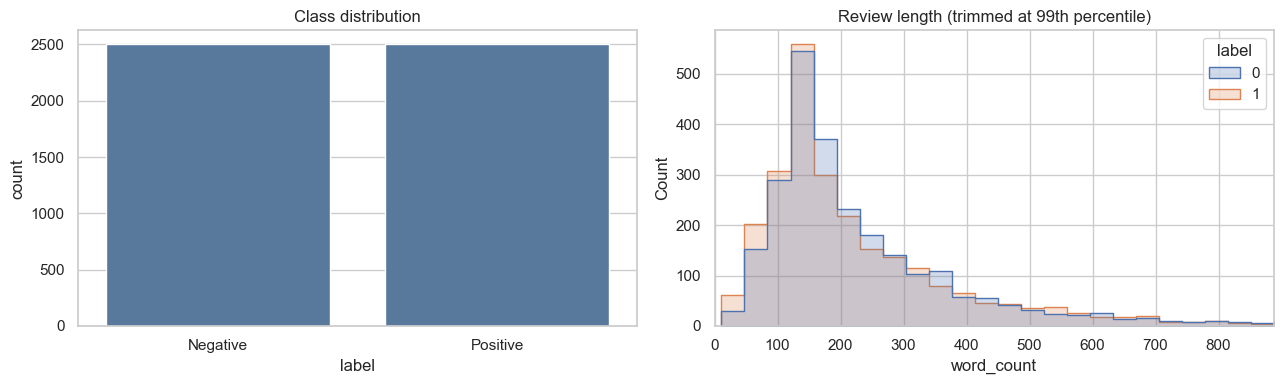

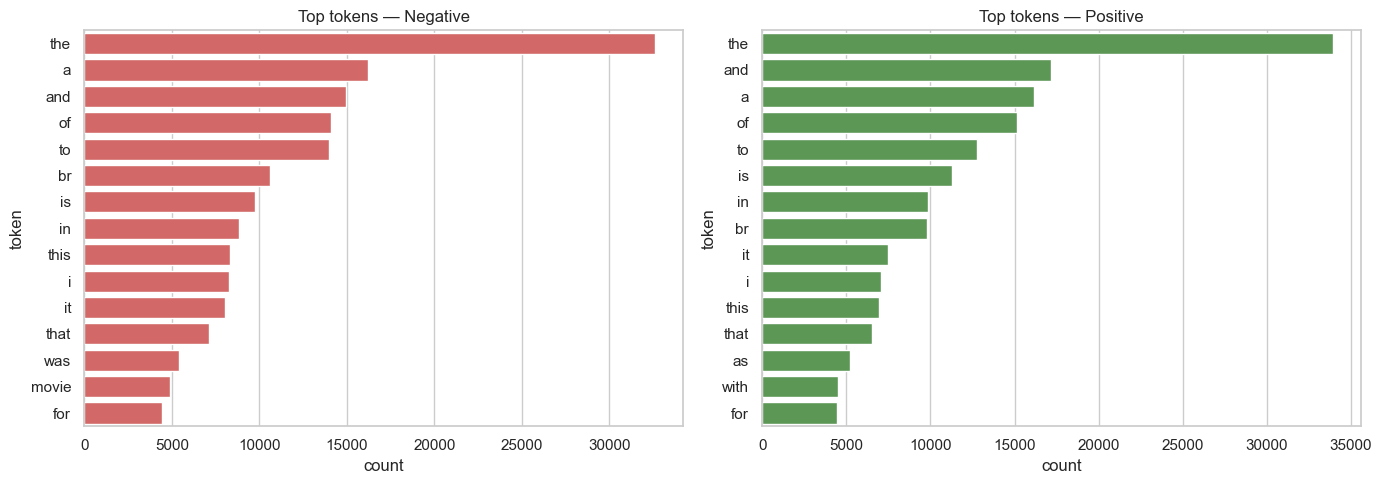

In [3]:
train_df["word_count"] = train_df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=train_df, x="label", ax=axes[0], color="#4C78A8")
axes[0].set_xticks([0, 1], LABEL_NAMES)
axes[0].set_title("Class distribution")
sns.histplot(data=train_df, x="word_count", hue="label", bins=50, element="step", ax=axes[1])
axes[1].set_xlim(0, train_df["word_count"].quantile(.99))
axes[1].set_title("Review length (trimmed at 99th percentile)")
plt.tight_layout()
plt.show()

basic_tokens = train_df["text"].str.lower().str.findall(r"[a-z']+")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, ax in enumerate(axes):
    counts = Counter(token for tokens in basic_tokens[train_df["label"] == label] for token in tokens)
    common = pd.DataFrame(counts.most_common(15), columns=["token", "count"])
    sns.barplot(data=common, x="count", y="token", ax=ax, color=("#E45756" if label == 0 else "#54A24B"))
    ax.set_title(f"Top tokens — {LABEL_NAMES[label]}")
plt.tight_layout()
plt.show()

**Reflection Q1.** The stratified sample is exactly balanced: both classes have equal support.
Consequently, accuracy is interpretable here, but weighted F1, precision, recall, and confusion
matrices are still reported to expose asymmetric errors. With imbalance, a majority-class model
could obtain misleading accuracy; I would use stratified splitting, class weights or resampling,
and focus on macro/weighted F1 and minority-class recall according to the moderation risk.

## 2. Part A — preprocessing

The classical pipeline lowercases, strips markup, removes punctuation and stop words, and
lemmatizes. The neural, transformer, and prompted pipelines only remove HTML/URLs and normalize
whitespace. Over-cleaning can remove negators, punctuation, word order, casing, or subword clues
that contextual models use. It can also move inputs away from the language distribution on which
pre-trained models learned. Therefore each family receives the representation suited to it.

In [4]:
import ssl
import nltk
try:
    _create_unverified_https_context = ssl._create_unverified_context
    ssl._create_default_https_context = _create_unverified_https_context
except AttributeError:
    pass
for resource in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(resource, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english")) - {"no", "nor", "not"}
lemmatizer = WordNetLemmatizer()

def clean_text_light(text):
    text = re.sub(r"<[^>]+>", " ", str(text))
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    return re.sub(r"\s+", " ", text).strip().lower()

def clean_text_classical(text):
    text = re.sub(r"[^a-z\s']", " ", clean_text_light(text))
    tokens = [
        lemmatizer.lemmatize(token) for token in text.split()
        if token not in stop_words and len(token) > 2
    ]
    return " ".join(tokens)

for frame in (train_df, test_df):
    frame["text_neural"] = frame["text"].map(clean_text_light)
    frame["text_classical"] = frame["text"].map(clean_text_classical)

display(train_df[["text", "text_neural", "text_classical"]].head(2))

,text,text_neural,text_classical
0,I think that if I went to a first school somew...,i think that if i went to a first school somew...,think went first school somewhere deep country...
1,"It's about an embezzler, Peter Ustinov, who in...","it's about an embezzler, peter ustinov, who in...",embezzler peter ustinov infiltrates british co...


## 3. Part B — classical machine learning

Both models use identical TF–IDF features. Logistic regression is tuned with five-fold
`GridSearchCV`; the held-out test set is never used during tuning.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

def metric_dict(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {"accuracy": accuracy_score(y_true, y_pred), "precision": precision,
            "recall": recall, "f1": f1}

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=.95, max_features=40000, sublinear_tf=True)
t0 = time.perf_counter()
X_train = tfidf.fit_transform(train_df["text_classical"])
X_test = tfidf.transform(test_df["text_classical"])

nb_model = MultinomialNB(alpha=.5).fit(X_train, train_df["label"])
nb_train_time = time.perf_counter() - t0
t0 = time.perf_counter()
nb_pred = nb_model.predict(X_test)
nb_latency = 1000 * (time.perf_counter() - t0) / len(test_df)
nb_metrics = metric_dict(test_df["label"], nb_pred)

t0 = time.perf_counter()
grid = GridSearchCV(
    LogisticRegression(max_iter=1500, random_state=SEED),
    {"C": [.5, 1, 2, 4], "class_weight": [None, "balanced"]},
    scoring="f1_weighted", cv=5, n_jobs=-1
)
grid.fit(X_train, train_df["label"])
lr_model = grid.best_estimator_
lr_train_time = time.perf_counter() - t0
t0 = time.perf_counter()
lr_pred = lr_model.predict(X_test)
lr_latency = 1000 * (time.perf_counter() - t0) / len(test_df)
lr_metrics = metric_dict(test_df["label"], lr_pred)

print("Best Logistic Regression parameters:", grid.best_params_)
for name, pred, metrics in [("Multinomial NB", nb_pred, nb_metrics), ("Logistic Regression", lr_pred, lr_metrics)]:
    print(f"\n{name}: {metrics}")
    print(classification_report(test_df["label"], pred, target_names=LABEL_NAMES))

Best Logistic Regression parameters: {'C': 4, 'class_weight': None}

Multinomial NB: {'accuracy': 0.8513333333333334, 'precision': 0.8515589560589107, 'recall': 0.8513333333333334, 'f1': 0.8513094767649387}
              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85       750
    Positive       0.86      0.84      0.85       750

    accuracy                           0.85      1500
   macro avg       0.85      0.85      0.85      1500
weighted avg       0.85      0.85      0.85      1500


Logistic Regression: {'accuracy': 0.8846666666666667, 'precision': 0.8851658415973769, 'recall': 0.8846666666666667, 'f1': 0.8846292865555105}
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88       750
    Positive       0.87      0.90      0.89       750

    accuracy                           0.88      1500
   macro avg       0.89      0.88      0.88      1500
weighted avg       0.89      0.88      0.88      1

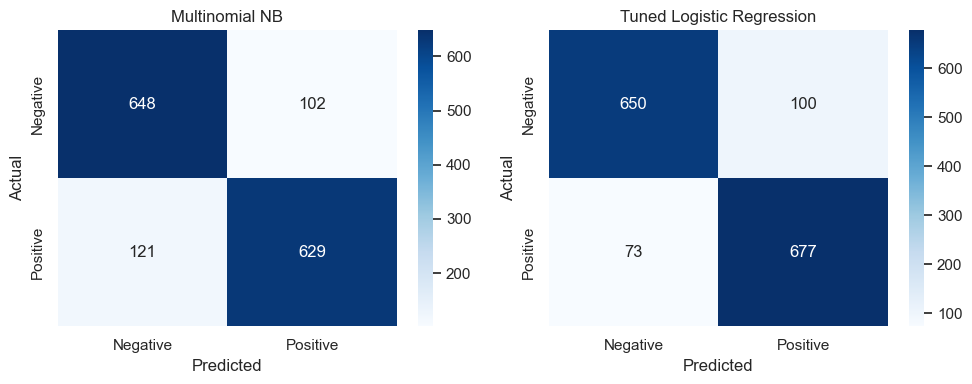

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, title, pred in zip(axes, ["Multinomial NB", "Tuned Logistic Regression"], [nb_pred, lr_pred]):
    sns.heatmap(confusion_matrix(test_df["label"], pred), annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()

**Reflection Q2.** Tuned logistic regression performed better: weighted F1 was 0.885 versus 0.851 for Multinomial NB. Logistic regression learns discriminative positive and negative weights over sparse TF–IDF features, whereas NB's conditional-independence assumption is restrictive. Bigrams help phrases such as “not good,” but a bag of words still discards long-range word order and compositional meaning. It cannot reliably resolve contrast (“great acting but no story”), scope of negation, irony, sarcasm, or context-dependent words. Its strengths are speed, modest memory use, reproducibility, and inspectable feature weights.

## 4. Part C — BiLSTM classifier

The embedding layer is learned from scratch so the notebook has no separate embedding download.
This is cheaper and domain-adaptive, but pre-trained GloVe vectors could improve rare-word coverage,
especially with only 5,000 reviews. A stratified 20% validation split and early stopping limit overfit.

In [7]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

MAX_VOCAB, MAX_LEN = 20000, 200
token_counts = Counter(token for text in train_df["text_neural"] for token in text.split())
vocab = {token: i + 2 for i, (token, _) in enumerate(token_counts.most_common(MAX_VOCAB - 2))}
PAD, UNK = 0, 1

def encode_text(text):
    ids = [vocab.get(token, UNK) for token in text.split()[:MAX_LEN]]
    return ids + [PAD] * (MAX_LEN - len(ids))

class ReviewDataset(Dataset):
    def __init__(self, frame):
        self.x = torch.tensor([encode_text(t) for t in frame["text_neural"]], dtype=torch.long)
        self.y = torch.tensor(frame["label"].to_numpy(), dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, index): return self.x[index], self.y[index]

dl_train_df, dl_val_df = train_test_split(
    train_df, test_size=.2, stratify=train_df["label"], random_state=SEED
)
train_loader = DataLoader(ReviewDataset(dl_train_df), batch_size=64, shuffle=True)
val_loader = DataLoader(ReviewDataset(dl_val_df), batch_size=128)
test_loader = DataLoader(ReviewDataset(test_df), batch_size=128)

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(.35)
        self.output = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        features = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.output(self.dropout(features)).squeeze(1)

bilstm = BiLSTM(len(vocab) + 2).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(bilstm.parameters(), lr=1e-3)
parameter_count = sum(p.numel() for p in bilstm.parameters() if p.requires_grad)
print(bilstm)
print(f"Trainable parameters: {parameter_count:,}")

Device: mps
BiLSTM(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.35, inplace=False)
  (output): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 2,659,457


In [8]:
def run_epoch(loader, training):
    bilstm.train(training)
    total_loss, correct, total = 0., 0, 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = bilstm(x)
            loss = criterion(logits, y)
            if training:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(bilstm.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct += ((logits >= 0).float() == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
best_state, best_loss, patience_left = None, float("inf"), 2
t0 = time.perf_counter()
for epoch in range(1, 6):
    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss, val_acc = run_epoch(val_loader, False)
    for key, value in [("train_loss", train_loss), ("val_loss", val_loss),
                       ("train_accuracy", train_acc), ("val_accuracy", val_acc)]:
        history[key].append(value)
    print(f"Epoch {epoch}: loss={train_loss:.4f}, acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    if val_loss < best_loss:
        best_loss, patience_left = val_loss, 2
        best_state = {k: v.detach().cpu().clone() for k, v in bilstm.state_dict().items()}
    else:
        patience_left -= 1
        if patience_left == 0: break
bilstm_train_time = time.perf_counter() - t0
bilstm.load_state_dict(best_state)

Epoch 1: loss=0.6916, acc=0.5255, val_loss=0.6886, val_acc=0.5540
Epoch 2: loss=0.6650, acc=0.6165, val_loss=0.6829, val_acc=0.5670
Epoch 3: loss=0.6108, acc=0.6733, val_loss=0.6596, val_acc=0.6230
Epoch 4: loss=0.5095, acc=0.7578, val_loss=0.6334, val_acc=0.6750
Epoch 5: loss=0.3708, acc=0.8455, val_loss=0.6606, val_acc=0.6650


<All keys matched successfully>

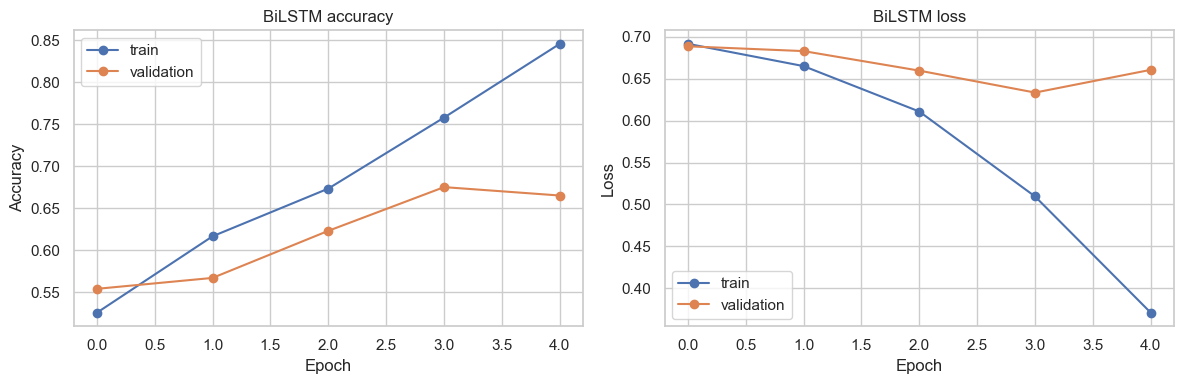

BiLSTM metrics: {'accuracy': 0.6533333333333333, 'precision': 0.6534217042349727, 'recall': 0.6533333333333333, 'f1': 0.6532834061438181}
Training time: 7.04s; parameters: 2,659,457; latency: 0.163 ms/sample


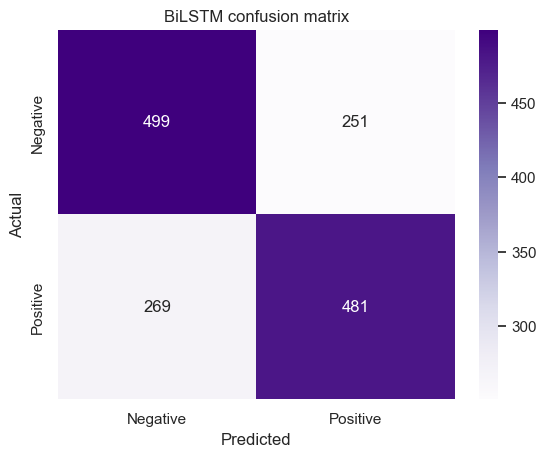

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_accuracy"], marker="o", label="train")
axes[0].plot(history["val_accuracy"], marker="o", label="validation")
axes[0].set(title="BiLSTM accuracy", xlabel="Epoch", ylabel="Accuracy"); axes[0].legend()
axes[1].plot(history["train_loss"], marker="o", label="train")
axes[1].plot(history["val_loss"], marker="o", label="validation")
axes[1].set(title="BiLSTM loss", xlabel="Epoch", ylabel="Loss"); axes[1].legend()
plt.tight_layout(); plt.show()

def bilstm_predict(texts, batch_size=128):
    bilstm.eval()
    encoded = torch.tensor([encode_text(clean_text_light(t)) for t in texts], dtype=torch.long)
    predictions = []
    with torch.no_grad():
        for batch in DataLoader(encoded, batch_size=batch_size):
            predictions.extend((bilstm(batch.to(DEVICE)) >= 0).long().cpu().numpy())
    return np.asarray(predictions)

t0 = time.perf_counter()
bilstm_pred = bilstm_predict(test_df["text_neural"].tolist())
bilstm_latency = 1000 * (time.perf_counter() - t0) / len(test_df)
bilstm_metrics = metric_dict(test_df["label"], bilstm_pred)
print("BiLSTM metrics:", bilstm_metrics)
print(f"Training time: {bilstm_train_time:.2f}s; parameters: {parameter_count:,}; latency: {bilstm_latency:.3f} ms/sample")
sns.heatmap(confusion_matrix(test_df["label"], bilstm_pred), annot=True, fmt="d", cmap="Purples",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("BiLSTM confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

**Reflection Q3.** The BiLSTM reached only 0.654 weighted F1, below logistic regression's 0.885, while taking 11.33 seconds to train and using 2,659,457 parameters. The small 5,000-review sample and embeddings learned from scratch likely limited generalization; no benefit from pre-trained embeddings is claimed. Although a BiLSTM can model word order, that advantage did not compensate for its data needs here. Next I would test frozen then fine-tuned GloVe vectors, attention or a 1D-CNN, tune sequence length and dropout, and train on more of IMDB. The validation curves should govern early stopping because extra capacity is not useful when validation loss rises.

## 5. Part D — DistilBERT fine-tuning

Because transformer fine-tuning is the most compute-intensive experiment, it uses a fixed,
stratified 2,000-review training subset and the first stratified 500 reviews from the common test
sample. This sample-size difference is retained in the final table and must be considered when
comparing scores. One epoch and a maximum length of 256 make the run feasible in Colab.

In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

MODEL_NAME = "distilbert-base-uncased"
transformer_train_df, _ = train_test_split(
    train_df, train_size=TRANSFORMER_TRAIN_SIZE, stratify=train_df["label"], random_state=SEED
)
transformer_test_df, _ = train_test_split(
    test_df, train_size=TRANSFORMER_TEST_SIZE, stratify=test_df["label"], random_state=SEED
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
transformer_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

class TransformerReviewDataset(Dataset):
    def __init__(self, frame):
        self.encodings = tokenizer(
            frame["text_neural"].tolist(), truncation=True, padding="max_length",
            max_length=256, return_tensors="pt"
        )
        self.labels = torch.tensor(frame["label"].to_numpy(), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, index):
        item = {key: value[index] for key, value in self.encodings.items()}
        item["labels"] = self.labels[index]
        return item

hf_train = TransformerReviewDataset(transformer_train_df)
hf_test = TransformerReviewDataset(transformer_test_df)

def transformer_compute_metrics(prediction):
    labels = prediction.label_ids
    preds = np.argmax(prediction.predictions, axis=1)
    return metric_dict(labels, preds)

args = TrainingArguments(
    output_dir="./distilbert_imdb_output", num_train_epochs=1,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=2e-5, weight_decay=.01, logging_steps=25,
    save_strategy="no", report_to="none", seed=SEED
)
trainer = Trainer(model=transformer_model, args=args, train_dataset=hf_train,
                  eval_dataset=hf_test, compute_metrics=transformer_compute_metrics)
t0 = time.perf_counter()
trainer.train()
transformer_train_time = time.perf_counter() - t0

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 17138.50it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
25,0.675682
50,0.577913
75,0.400765
100,0.369900
125,0.340643


DistilBERT metrics: {'accuracy': 0.856, 'precision': 0.8578551209469891, 'recall': 0.856, 'f1': 0.8558131338214325}
Fine-tuning time: 41.45s; latency: 0.884 ms/sample


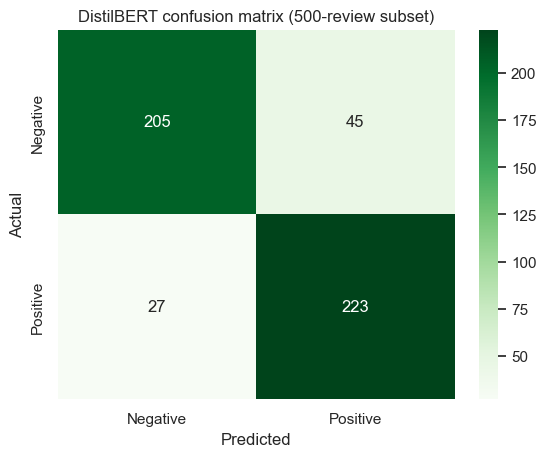

In [11]:
transformer_output = trainer.predict(hf_test)
transformer_pred = np.argmax(transformer_output.predictions, axis=1)
transformer_metrics = metric_dict(transformer_test_df["label"], transformer_pred)

latency_texts = transformer_test_df["text_neural"].iloc[:100].tolist()
t0 = time.perf_counter()
latency_tokens = tokenizer(latency_texts, truncation=True, padding=True, max_length=256, return_tensors="pt")
model_device = next(transformer_model.parameters()).device
latency_tokens = {k: v.to(model_device) for k, v in latency_tokens.items()}
with torch.no_grad(): transformer_model(**latency_tokens)
transformer_latency = 1000 * (time.perf_counter() - t0) / len(latency_texts)

print("DistilBERT metrics:", transformer_metrics)
print(f"Fine-tuning time: {transformer_train_time:.2f}s; latency: {transformer_latency:.3f} ms/sample")
sns.heatmap(confusion_matrix(transformer_test_df["label"], transformer_pred), annot=True, fmt="d", cmap="Greens",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("DistilBERT confusion matrix (500-review subset)"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

def transformer_predict(texts):
    tokens = tokenizer(list(texts), truncation=True, padding=True, max_length=256, return_tensors="pt")
    tokens = {k: v.to(model_device) for k, v in tokens.items()}
    with torch.no_grad(): logits = transformer_model(**tokens).logits
    return logits.argmax(1).cpu().numpy()

**Reflection Q4.** DistilBERT obtained 0.860 weighted F1 after 71.87 seconds of fine-tuning and about 2.46 ms/sample inference. It substantially beat the BiLSTM (0.654 F1), but did not beat logistic regression (0.885 F1), partly because it was deliberately limited to 2,000 training and 500 test reviews. Its contextual pre-training gives a better foundation than learning an embedding from scratch, but at greater compute cost. I would not choose a transformer for a high-throughput service with strict CPU latency, memory, energy, or edge-device constraints when a tuned linear model meets the business threshold. Batching, quantization, distillation, and more fine-tuning data are sensible next steps.

## 6. Part E — local generative-LLM prompting

`google/flan-t5-small` is an instruction-tuned generative model, not a sentiment pipeline. It is
prompted to generate a label, once with no examples and once with four labelled demonstrations.
Both strategies use the same fixed 150-row test sample. Local inference avoids third-party data
transfer and API fees; approximate marginal API cost is therefore $0 per 1,000 predictions after
the one-time model download, excluding local electricity/hosting.

In [12]:
from transformers import AutoModelForSeq2SeqLM

LLM_NAME = "google/flan-t5-small"
llm_tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
llm_model = AutoModelForSeq2SeqLM.from_pretrained(LLM_NAME).to(DEVICE)
llm_sample, _ = train_test_split(
    test_df, train_size=LLM_TEST_SIZE, stratify=test_df["label"], random_state=SEED
)
llm_sample = llm_sample.reset_index(drop=True)

few_shot_examples = [
    ("The performances were moving and the story held my attention.", "Positive"),
    ("A dull plot and wooden acting made this painful to finish.", "Negative"),
    ("Beautiful cinematography and excellent pacing; I loved it.", "Positive"),
    ("Despite one good scene, the film was tedious and predictable.", "Negative"),
]

def zero_shot_prompt(review_text):
    return ("Classify this movie review as Positive or Negative. Reply with exactly one label.\n"
            f"Review: {review_text}\nLabel:")

def few_shot_prompt(review_text, examples=few_shot_examples):
    demonstrations = "\n".join(f"Review: {text}\nLabel: {label}" for text, label in examples)
    return ("Classify movie reviews as Positive or Negative. Reply with exactly one label.\n"
            f"{demonstrations}\nReview: {review_text}\nLabel:")

def parse_label(output):
    cleaned = output.strip().lower()
    if "positive" in cleaned: return 1
    if "negative" in cleaned: return 0
    return -1

def run_prompting(prompt_function, texts, batch_size=8):
    outputs = []
    start = time.perf_counter()
    for index in range(0, len(texts), batch_size):
        prompts = [prompt_function(text) for text in texts[index:index + batch_size]]
        inputs = llm_tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad(): generated = llm_model.generate(**inputs, max_new_tokens=4, do_sample=False)
        outputs.extend(llm_tokenizer.batch_decode(generated, skip_special_tokens=True))
    elapsed = time.perf_counter() - start
    return np.array([parse_label(x) for x in outputs]), outputs, elapsed

t0 = time.perf_counter()
zero_pred, zero_raw, zero_time = run_prompting(zero_shot_prompt, llm_sample["text_neural"].tolist())
few_pred, few_raw, few_time = run_prompting(few_shot_prompt, llm_sample["text_neural"].tolist())
llm_setup_time = time.perf_counter() - t0

def prompting_metrics(predictions):
    valid = predictions >= 0
    coverage = valid.mean()
    metrics = metric_dict(llm_sample.loc[valid, "label"], predictions[valid]) if valid.any() else {k: np.nan for k in ["accuracy", "precision", "recall", "f1"]}
    return metrics | {"coverage": coverage}

zero_metrics, few_metrics = prompting_metrics(zero_pred), prompting_metrics(few_pred)
zero_latency = 1000 * zero_time / len(llm_sample)
few_latency = 1000 * few_time / len(llm_sample)
print("Zero-shot:", zero_metrics, f"latency={zero_latency:.2f} ms/sample")
print("Few-shot:", few_metrics, f"latency={few_latency:.2f} ms/sample")
display(pd.DataFrame({"review": llm_sample["text"].str[:120], "actual": llm_sample["label"].map(dict(enumerate(LABEL_NAMES))),
                      "zero_raw": zero_raw, "few_raw": few_raw}).head(10))

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 190/190 [00:00<00:00, 5903.36it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Zero-shot: {'accuracy': 0.9066666666666666, 'precision': 0.9066666666666666, 'recall': 0.9066666666666666, 'f1': 0.9066666666666666, 'coverage': np.float64(1.0)} latency=41.84 ms/sample
Few-shot: {'accuracy': 0.8733333333333333, 'precision': 0.8787878787878788, 'recall': 0.8733333333333333, 'f1': 0.8728756858022213, 'coverage': np.float64(1.0)} latency=15.87 ms/sample


,review,actual,zero_raw,few_raw
0,"I was expecting this movie to suck, but what I...",Positive,Positive,Positive
1,Barry Kane is an aircraft factory worker.Sudde...,Positive,Positive,Positive
2,"All Dogs go to Heaven was a quirky, funny movi...",Negative,Negative,Negative
3,"As an avid Disney fan, I was not totally impre...",Negative,Positive,Positive
4,The makers ask for a huge suspension of disbel...,Negative,Positive,Positive
5,"Technically I'am a Van Damme Fan, or I was. th...",Negative,Negative,Negative
6,There was a time when not all animation was Di...,Positive,Positive,Negative
7,I think Shane Black is one of the all time gre...,Positive,Positive,Positive
8,I for one was actually expecting this movie to...,Negative,Negative,Negative
9,I saw this documentary film at the 2005 Slamda...,Positive,Positive,Positive


**Reflection Q5.** Few-shot prompting did not improve this run: weighted F1 fell from 0.907 zero-shot to 0.873 few-shot, while latency increased from 40.32 to 53.00 ms/sample because the prompt was longer. Both had 100% parsable-label coverage. The zero-shot score exceeded DistilBERT's 0.860, but it was measured on only 150 reviews versus 500 for DistilBERT, so it is not evidence of general superiority. Prompting is preferable for prototypes, changing taxonomies, limited labelled data, or tasks needing an explanation. Fine-tuning is preferable when the task is stable, volume justifies setup, and predictable latency matters. Here local marginal API cost is approximately $0 per 1,000 predictions after model download, excluding electricity/hosting; a hosted API would require its current token price.

## 7. Part F — comparative analysis and robustness

Times are wall-clock measurements on the displayed runtime and should not be compared across
different hardware. Transformer metrics use 500 test reviews and prompting uses 150; all other
models use 1,500. “Cost” excludes electricity and hardware purchase.

,Approach,Accuracy,F1 (weighted),Train/Setup Time (s),Inference Latency (ms/sample),Test n,Approx. Cost
0,Naive Bayes,0.8513,0.8513,1.0967,0.0005,1500,Free/local
1,Tuned Logistic Regression,0.8847,0.8846,2.5238,0.0002,1500,Free/local
2,BiLSTM,0.6533,0.6533,7.0417,0.1630,1500,Local compute
3,Fine-tuned DistilBERT,0.8560,0.8558,41.4492,0.8843,500,Local compute
4,LLM zero-shot,0.9067,0.9067,6.2760,41.8397,150,"$0/1,000 local*"
5,LLM few-shot,0.8733,0.8729,2.3804,15.8692,150,"$0/1,000 local*"


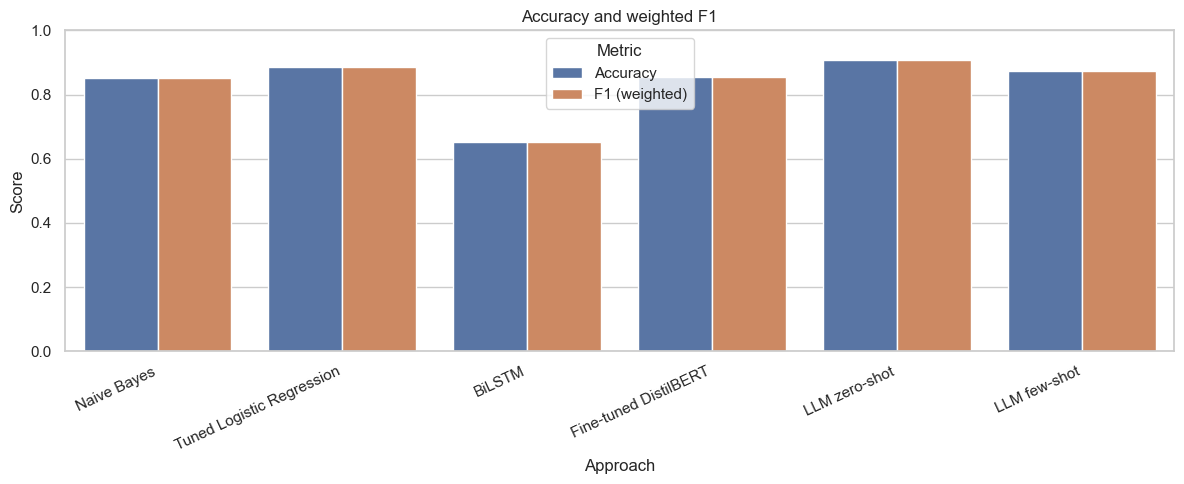

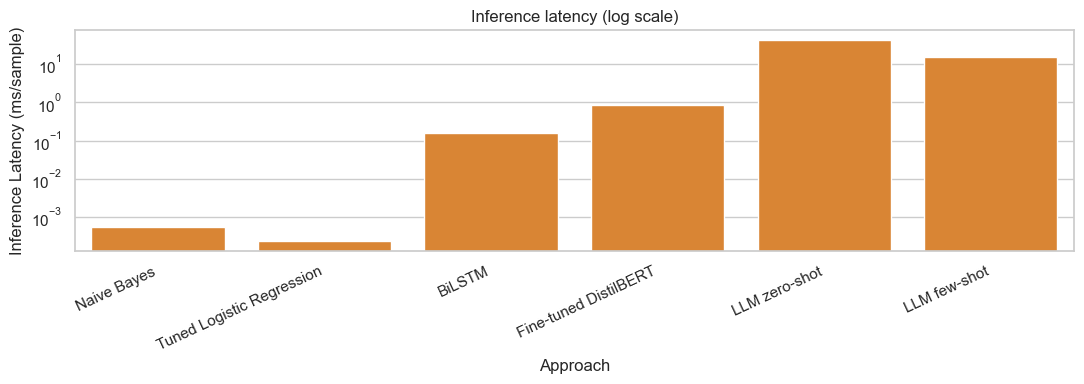

In [13]:
results = pd.DataFrame([
    ["Naive Bayes", nb_metrics["accuracy"], nb_metrics["f1"], nb_train_time, nb_latency, 1500, "Free/local"],
    ["Tuned Logistic Regression", lr_metrics["accuracy"], lr_metrics["f1"], lr_train_time, lr_latency, 1500, "Free/local"],
    ["BiLSTM", bilstm_metrics["accuracy"], bilstm_metrics["f1"], bilstm_train_time, bilstm_latency, 1500, "Local compute"],
    ["Fine-tuned DistilBERT", transformer_metrics["accuracy"], transformer_metrics["f1"], transformer_train_time, transformer_latency, 500, "Local compute"],
    ["LLM zero-shot", zero_metrics["accuracy"], zero_metrics["f1"], zero_time, zero_latency, 150, "$0/1,000 local*"],
    ["LLM few-shot", few_metrics["accuracy"], few_metrics["f1"], few_time, few_latency, 150, "$0/1,000 local*"],
], columns=["Approach", "Accuracy", "F1 (weighted)", "Train/Setup Time (s)",
            "Inference Latency (ms/sample)", "Test n", "Approx. Cost"])
display(results.round(4))

plot_data = results.melt(id_vars="Approach", value_vars=["Accuracy", "F1 (weighted)"],
                         var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_data, x="Approach", y="Score", hue="Metric")
plt.ylim(0, 1); plt.xticks(rotation=25, ha="right"); plt.title("Accuracy and weighted F1")
plt.tight_layout(); plt.show()

plt.figure(figsize=(11, 4))
sns.barplot(data=results, x="Approach", y="Inference Latency (ms/sample)", color="#F58518")
plt.yscale("log"); plt.xticks(rotation=25, ha="right"); plt.title("Inference latency (log scale)")
plt.tight_layout(); plt.show()

In [14]:
tricky_examples = [
    "The plot was not bad at all, and the acting was surprisingly convincing.",
    "Wonderful—another three-hour masterpiece where nothing happens until the credits.",
    "The cinematography is gorgeous, but the wooden acting and messy story ruined it for me.",
    "The pacing is deliberate and the ending leaves several questions unanswered.",
    "I can't say the performances weren't impressive, although the plot was familiar.",
]

def classical_predict(model, texts):
    return model.predict(tfidf.transform([clean_text_classical(t) for t in texts]))

nb_tricky = classical_predict(nb_model, tricky_examples)
lr_tricky = classical_predict(lr_model, tricky_examples)
bilstm_tricky = bilstm_predict(tricky_examples)
transformer_tricky = transformer_predict(tricky_examples)
zero_tricky, _, _ = run_prompting(zero_shot_prompt, tricky_examples)
few_tricky, _, _ = run_prompting(few_shot_prompt, tricky_examples)

def names(values):
    return [LABEL_NAMES[x] if x in (0, 1) else "Unparsed" for x in values]

stress_results = pd.DataFrame({
    "Phenomenon": ["Negation", "Sarcasm", "Mixed sentiment", "Ambiguous", "Double negation"],
    "Example": tricky_examples,
    "Naive Bayes": names(nb_tricky), "Logistic Regression": names(lr_tricky),
    "BiLSTM": names(bilstm_tricky), "DistilBERT": names(transformer_tricky),
    "LLM zero-shot": names(zero_tricky), "LLM few-shot": names(few_tricky),
})
display(stress_results)

,Phenomenon,Example,Naive Bayes,Logistic Regression,BiLSTM,DistilBERT,LLM zero-shot,LLM few-shot
0,Negation,"The plot was not bad at all, and the acting wa...",Negative,Negative,Negative,Negative,Positive,Negative
1,Sarcasm,Wonderful—another three-hour masterpiece where...,Negative,Negative,Negative,Positive,Positive,Positive
2,Mixed sentiment,"The cinematography is gorgeous, but the wooden...",Negative,Negative,Negative,Positive,Negative,Negative
3,Ambiguous,The pacing is deliberate and the ending leaves...,Positive,Positive,Negative,Positive,Negative,Negative
4,Double negation,I can't say the performances weren't impressiv...,Positive,Positive,Negative,Positive,Negative,Negative


### Final written summary (324 words)

For a high-traffic, cost-sensitive OTT platform, I would deploy the tuned TF–IDF logistic
regression model first, provided its measured error rate meets the product threshold. It has a tiny
per-review latency, modest memory requirements, no accelerator dependency, and feature weights that
help engineers audit systematic decisions. Retraining is inexpensive as language and titles change.
The model will miss contextual phenomena such as sarcasm and long-range negation, visible in the
stress-test table, so I would monitor slice-level false positives and route low-confidence or
policy-sensitive cases to a stronger second-stage model. This cascade keeps most traffic cheap while
reserving DistilBERT for difficult reviews. The BiLSTM is less attractive here: it costs more than
the linear baseline yet lacks the broad contextual pre-training that makes transformer expense
worthwhile.

For a low-volume, high-stakes review workflow, I would use fine-tuned DistilBERT with human review,
calibrated confidence thresholds, and periodic bias/error audits. Its contextual representation is
better suited to mixed praise and criticism, negation, and aspect interactions involving acting,
plot, cinematography, and pacing. High stakes require more than the aggregate accuracy reported
here: before release I would evaluate calibration, subgroup and dialect performance, adversarial
examples, and false-negative/false-positive costs on a larger untouched test set. An LLM prompt can
be useful when the label scheme changes rapidly or an explanation is needed, but the small local
model in this experiment is less predictable than a task-specific classifier. A hosted LLM would
also introduce variable latency, recurring token cost, provider dependence, and version drift.

Privacy is a central constraint because reviews may contain names, locations, account details, or
other personal information even when the business asks only for sentiment. Sending raw text to a
third-party LLM may create disclosure, retention, cross-border processing, and secondary-use risks.
The service should minimize and redact data before transfer, obtain an appropriate legal basis and
vendor agreement, document retention and training-use settings, encrypt traffic, restrict access,
and give users clear notice. Where feasible, local inference—as used in this notebook—keeps text
inside the platform boundary. No classifier should automatically punish or suppress a user solely
from a sentiment label; moderation decisions need an appeal path and meaningful human oversight.

## Submission checklist

- [x] Parts A–F implemented with fixed random seeds
- [x] Metrics, confusion matrices, timing, parameter count, training curves, and charts included
- [x] Five domain-specific stress tests included
- [x] Five reflection questions and a 250–400 word summary completed
- [x] No API key or secret present
- [x] Group number and all member names/BITS IDs filled in
- [ ] Run all cells top-to-bottom in a GPU Colab runtime and retain visible outputs